# Transportation Flow Network: 2015 NYC yellow taxis

One narrative pass over the pipeline. Every number here is read from
`data/processed/metrics_summary.json` (produced by `pixi run pipeline`); every
figure is in `figures/`. Run the pipeline first, then run this notebook top to bottom.

The network: nodes are TLC taxi zones; a directed edge i to j is the count of 2015
yellow-taxi trips from zone i to zone j. See `MODERNIZATION_NOTES.md` for why the
geography is zones rather than the original census tracts.

In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
res = json.load(open(ROOT / "data/processed/metrics_summary.json"))
FIG = ROOT / "figures"
def show(name): display(Image(filename=str(FIG / f"{name}.png")))
res["graph"]

{'total_trips': 142199201,
 'self_loop_trips': 6460370,
 'self_loop_share_pct': 4.543,
 'n_nodes_total': 260,
 'n_nodes_active': 262,
 'n_edges_full': 42347,
 'edge_weight_threshold': 500,
 'n_nodes_filtered': 228,
 'n_edges_filtered': 7945,
 'blog_tract_nodes': 580,
 'blog_top_edges': 1275,
 'n_zones_geocoded': 260,
 'n_nodes_table': 263}

## 1. From 146 million trips to a small network

After cleaning (97.4% of rows kept) the trips collapse onto a compact directed graph dominated by a few Midtown zones.

total trips kept : 142,199,201
self-loop share : 4.543%
active nodes / edges : 262 / 42,347
filtered (>500/yr) : 228 nodes, 7,945 edges


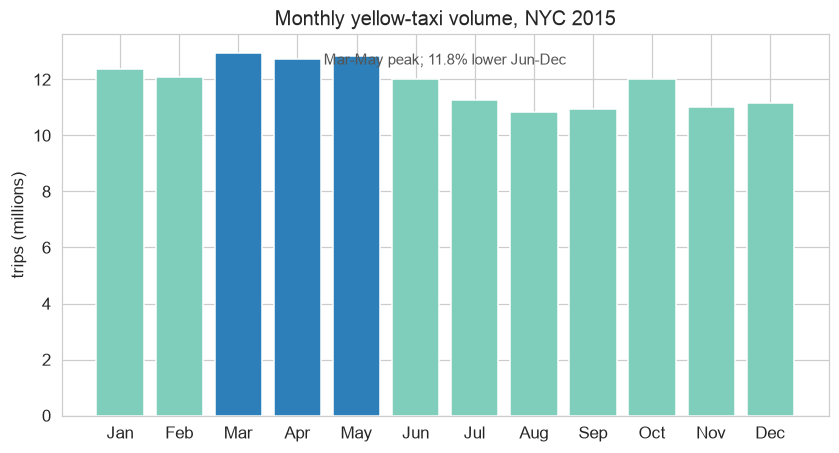

In [2]:
g = res["graph"]
print(f"total trips kept : {g['total_trips']:,}")
print(f"self-loop share : {g['self_loop_share_pct']}%")
print(f"active nodes / edges : {g['n_nodes_active']} / {g['n_edges_full']:,}")
print(f"filtered (>500/yr) : {g['n_nodes_filtered']} nodes, {g['n_edges_filtered']:,} edges")
show("01_monthly_volume")

## 2. Hubs, and the asymmetry between them

Inner-city draws pull huge volume from a small Manhattan origin set; airports pull from many scattered origins, so their trips-per-source is far lower.

In [3]:
pd.DataFrame(res["metrics"]["hub_asymmetry"]).T[["zone","trips_per_source","in_strength","in_degree"]]

,zone,trips_per_source,in_strength,in_degree
penn_station,Penn Station/Madison Sq West,17399.3,3897451,224
midtown_center,Midtown Center,22929.1,5159038,225
times_sq,Times Sq/Theatre District,18664.2,4348768,233
jfk,JFK Airport,4510.2,1123029,249
laguardia,LaGuardia Airport,7289.0,1727487,237
east_village,East Village,16142.5,3535216,219
lower_east_side,Lower East Side,7736.2,1593653,206


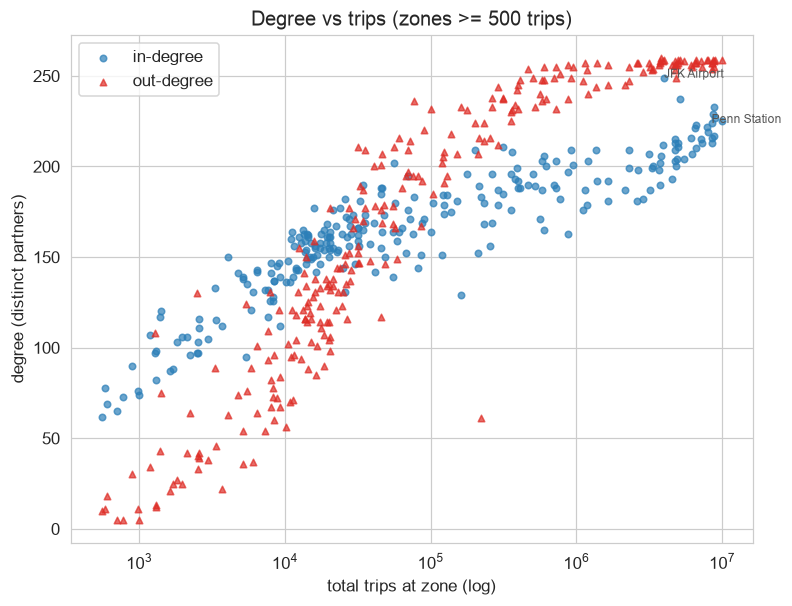

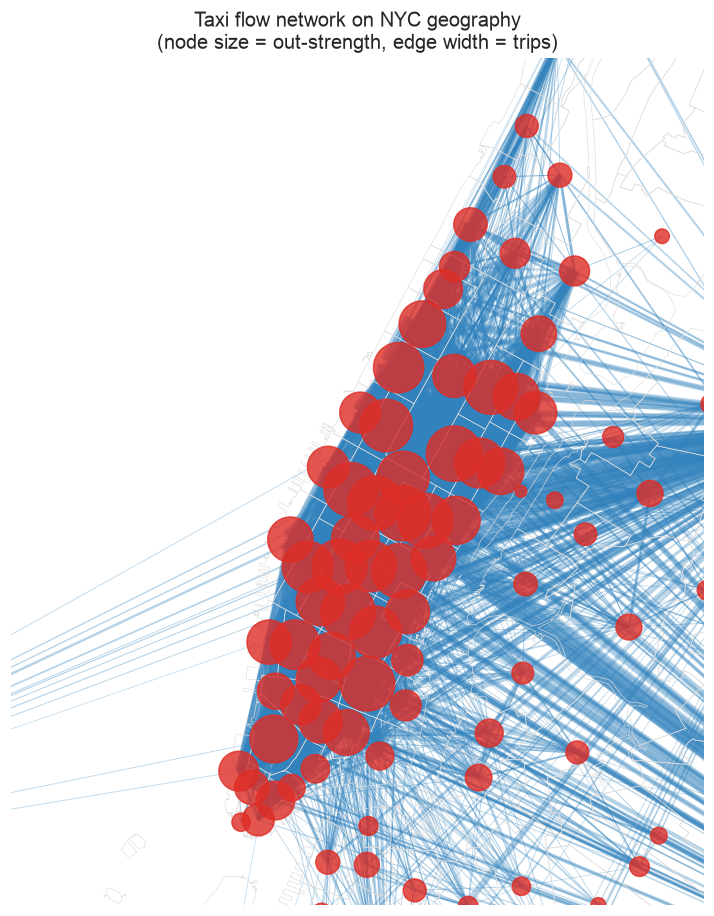

In [4]:
show("06_degree_vs_trips"); show("05_hub_map_geographic")

## 3. Taxi flows obey a gravity law, and the residual is the story

A doubly-constrained gravity model conditions on each zone's own volume and on distance. The residual is where the structure hides. Blue = under-connected given location; red = over-connected.

decay exponent (doubly-constrained): 1.146
CPC (goodness of fit) : 0.816

most UNDER-connected core zones:
 Upper East Side North        -20.3
 Upper West Side South        -16.3
 Upper East Side South        -16.1
 Upper West Side North        -15.7
 Lincoln Square East          -12.3
 Manhattan Valley             -11.3

East Village / Lower East Side:
 East Village                 -5.09 (pct 0.291)
 Alphabet City                -4.30 (pct 0.345)
 Two Bridges/Seward Park      -1.82 (pct 0.6)
 Chinatown                    -0.10 (pct 0.764)
 Lower East Side              +0.77 (pct 0.836)


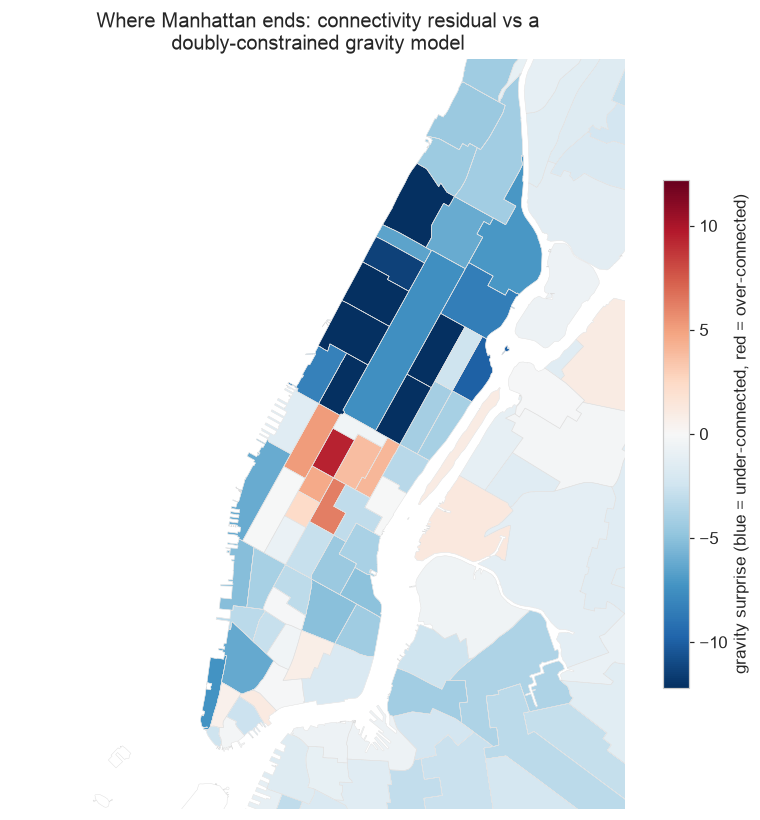

In [5]:
gr = res["analysis"]["gravity_residual_field"]
print("decay exponent (doubly-constrained):", gr["beta_doubly_constrained"])
print("CPC (goodness of fit) :", gr["cpc_doubly_constrained"])
print("\nmost UNDER-connected core zones:")
for x in gr["most_underconnected_core_zones"][:6]: print(f" {x['zone']:28s} {x['surprise']:+.1f}")
print("\nEast Village / Lower East Side:")
for x in gr["east_village_les_in_core"]: print(f" {x['zone']:28s} {x['surprise']:+.2f} (pct {x['core_percentile']})")
show("08_where_manhattan_ends")

## 4. The day/night reversal

The East Village and Lower East Side are peripheral by day and the busiest destinations at night; net flow flips sign between morning and evening, the mirror of the central business district.

destination rank, day -> night:
 East Village                  42 ->   1
 Lower East Side               51 ->   6
 Greenwich Village North       29 ->  29
 Meatpacking/West Village West  41 ->  19
 Clinton East                  22 ->   2


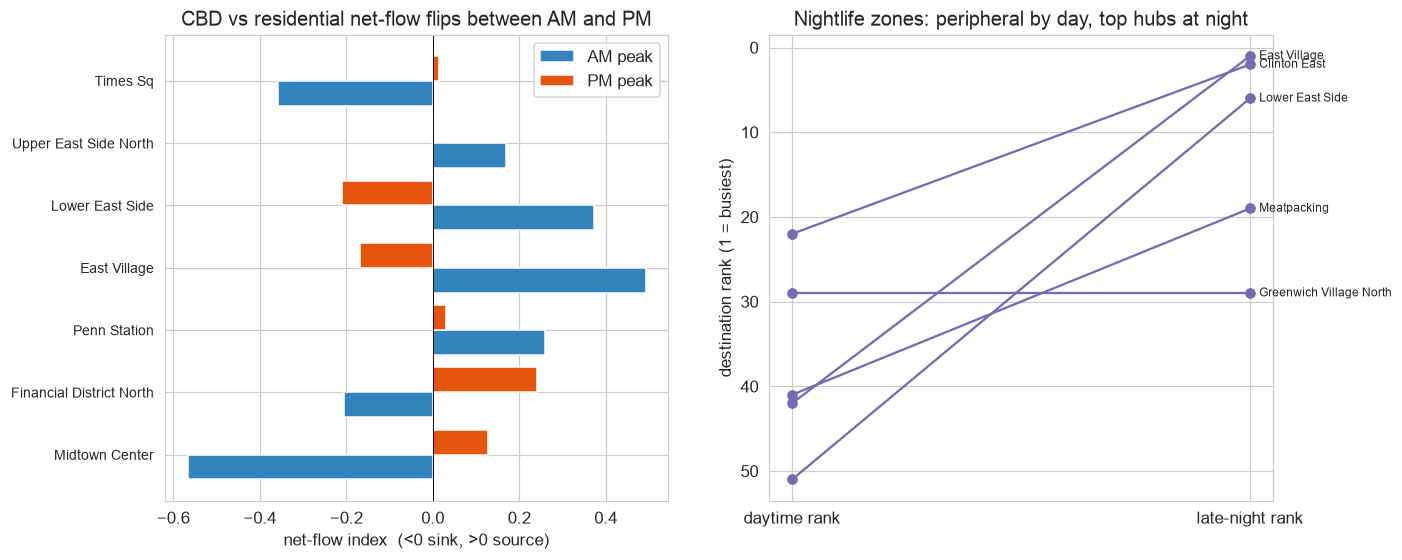

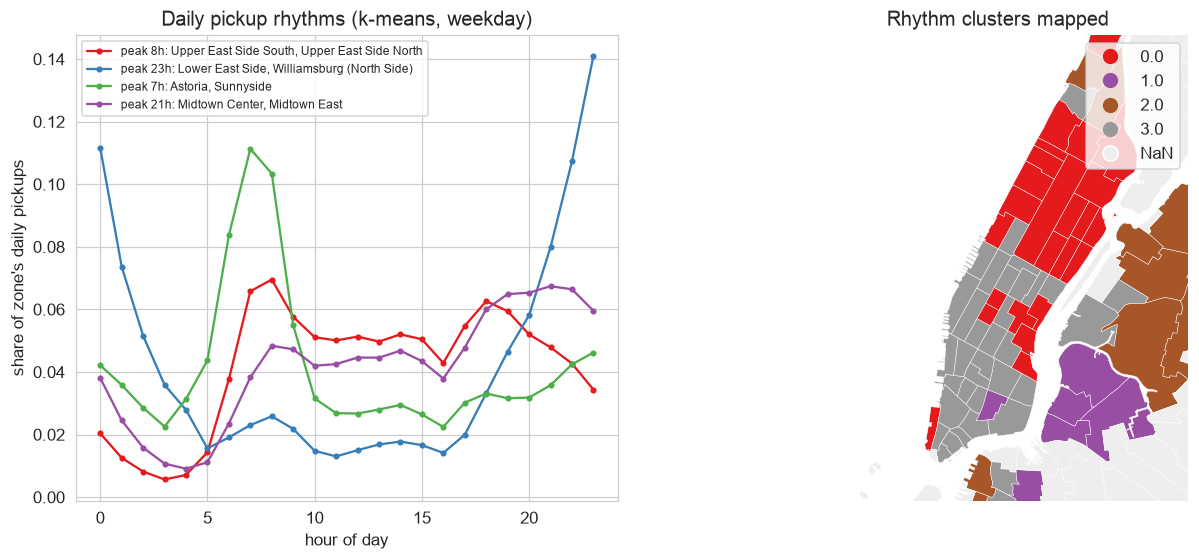

In [6]:
tn = res["analysis"]["temporal_networks"]
print("destination rank, day -> night:")
for z, d in tn["nightlife_rank_shift"].items(): print(f" {z:28s} {d['am_rank']:>3} -> {d['night_rank']:>3}")
show("10_day_night_reversal"); show("15_daily_rhythms")

## 5. Communities, measured for stability and significance

Four communities, seed-stable, significant against a null, cutting across borough lines.

leiden: {'n_communities': 4, 'modularity': 0.1893}
seed stability: {'n_runs': 100, 'community_count_mode': 4, 'community_count_range': [3, 4], 'mean_ARI': 0.751, 'min_ARI': 0.421, 'mean_AMI': 0.737, 'n_pairs': 4950}
modularity significance: {'null': 'weight-concentration: edge weights reshuffled, topology and Leiden partition fixed (tests that the partition groups high-flow edges)', 'Q_observed': 0.1893, 'Q_null_mean': -0.0216, 'z_score': 13.8}
vs administrative geography: {'leiden_vs_borough_AMI': 0.387, 'leiden_vs_borough_ARI': 0.25, 'leiden_vs_servicezone_AMI': 0.237}


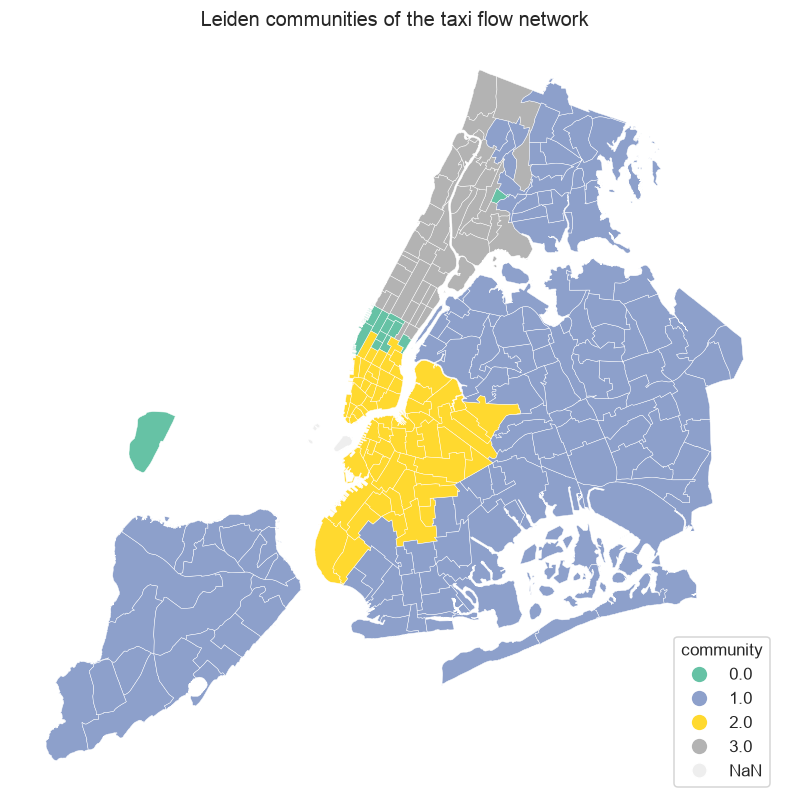

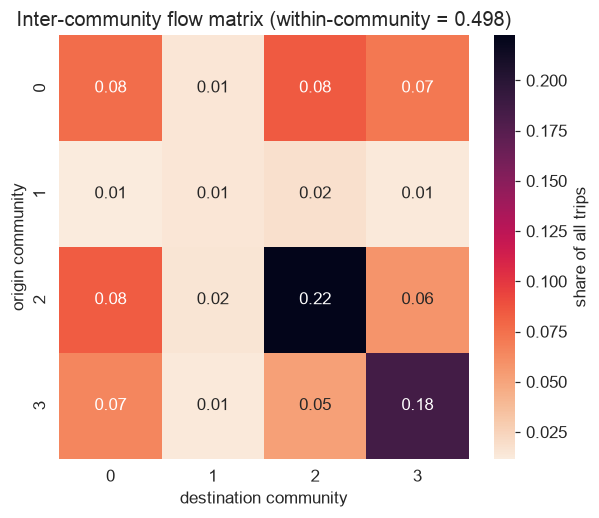

In [7]:
cm = res["analysis"]["communities"]
print("leiden:", cm["algorithms"]["leiden_modularity"])
print("seed stability:", cm["seed_stability"])
print("modularity significance:", cm["modularity_significance"])
print("vs administrative geography:", cm["vs_administrative"])
show("07_community_map"); show("16_intercommunity_flow")

## 6. Reproduced and explained

The constant-cost band is the JFK flat fare, not rounded tips; the structure is reciprocal and disassortative; the backbone is principled.

cost band: {'sample_size': 300000, 'jfk_flatfare_share_pct': 2.029, 'jfk_fare_median': 52.0, 'jfk_fare_iqr': [52.0, 52.0], 'constant_band_49_53_share_pct': 2.187, 'constant_band_is_jfk_pct': 92.7}
structure: {'weighted_reciprocity': 0.818, 'garlaschelli_loffredo_rho': 0.515, 'mean_flow_imbalance': 0.603, 'median_flow_imbalance': 0.678, 'degree_assortativity': -0.184, 'max_kcore': 147}
backbone : {'alpha': 0.05, 'backbone_edges': 6190, 'backbone_nodes': 262, 'backbone_trip_share_pct': 87.6, 'threshold_edges': 7945, 'threshold_trip_share_pct': 98.6, 'full_edges': 42347}


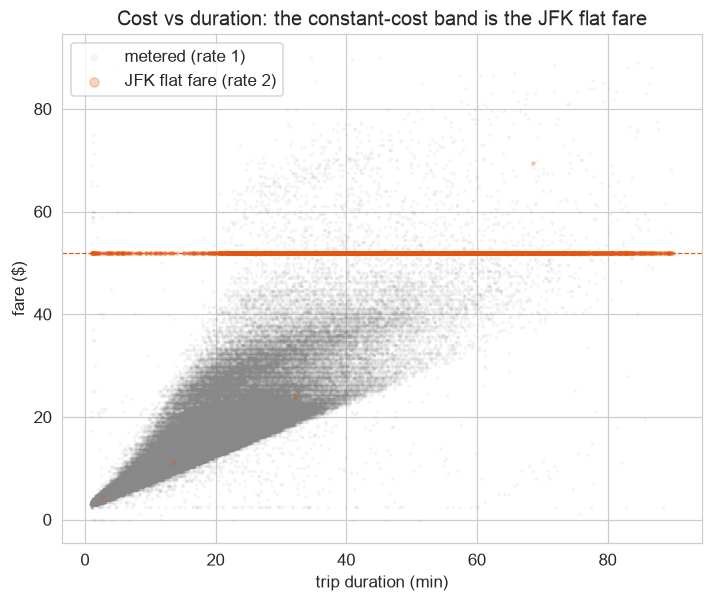

In [8]:
print("cost band:", res["temporal"]["cost_duration"])
print("structure:", res["analysis"]["structure"])
print("backbone :", res["analysis"]["backbone"])
show("04_cost_vs_duration")

See `docs/paper.md` for the full writeup and `figures/CAPTIONS.md` for every figure with its caption.